In [31]:
import pandas as pd

file_path = 'C:\\Users\\lollo\\Lavoro\\Ricerca\\energiai\\dataset\\sims\\Mario_Rossi.csv'
df = pd.read_csv(file_path)

df.head()

,x,y,z,w,name,room,bedroom,livingroom,kitchen,bathroom,...,hygiene,hunger,bladder,social,energy,fun,elapsed_time,hour,minute,weekday
0,1120.92,45.89624,1022.806,1,Mario Rossi,Kitchen,0,0,1,0,...,89.24345,88.97398,90.43717,97.83731,81.88425,0.0,29113.6,8.087111,5.226685,Sunday
1,1120.92,45.89624,1022.806,1,Mario Rossi,Kitchen,0,0,1,0,...,89.24345,88.97398,90.43717,97.83731,81.88425,0.0,29124.8,8.090222,5.413330,Sunday
2,1120.92,45.89624,1022.806,1,Mario Rossi,Kitchen,0,0,1,0,...,89.24345,88.97398,90.43717,97.83731,81.88425,0.0,29126.4,8.090667,5.440002,Sunday
3,1120.92,45.89624,1022.806,1,Mario Rossi,Kitchen,0,0,1,0,...,89.24345,88.97398,90.43717,97.83731,81.88425,0.0,29128.0,8.091111,5.466675,Sunday
4,1120.92,45.89624,1022.806,1,Mario Rossi,Kitchen,0,0,1,0,...,89.24345,88.97398,90.43717,97.83731,81.88425,0.0,29129.6,8.091556,5.493347,Sunday


In [3]:
white_list = [
        'x',
        'y',
        'bedroom',
        'livingroom',
        'kitchen',
        'bathroom',
        # 'elapsed_time_cumulative',
        'elapsed_time',
        # 'exceeds_average'  
    ]

df = df[white_list]
df.head

<bound method NDFrame.head of                x         y  bedroom  livingroom  kitchen  bathroom  \
0       1120.920  45.89624        0           0        1         0   
1       1120.920  45.89624        0           0        1         0   
2       1120.920  45.89624        0           0        1         0   
3       1120.920  45.89624        0           0        1         0   
4       1120.920  45.89624        0           0        1         0   
...          ...       ...      ...         ...      ...       ...   
162130  1131.821  45.89624        1           0        0         0   
162131  1131.821  45.89624        1           0        0         0   
162132  1131.821  45.89624        1           0        0         0   
162133  1131.821  45.89624        1           0        0         0   
162134  1131.821  45.89624        1           0        0         0   

        elapsed_time  
0            29113.6  
1            29124.8  
2            29126.4  
3            29128.0  
4            2

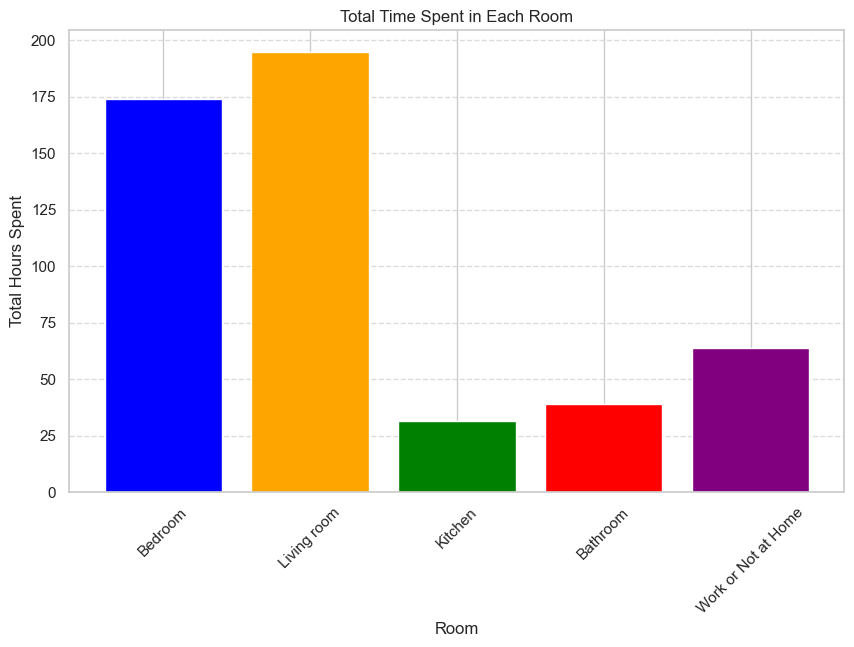

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import argparse
import seaborn as sns

def read_csv_file(file_path):
    df = pd.read_csv(file_path)
    data_points = df.to_dict(orient='records')
    return data_points

def plot_total_time_in_room(data_points):
    room_categories = ["Bedroom", "Living room", "Kitchen", "Bathroom", "Work or Not at Home"]
    total_room_time = {room: 0 for room in room_categories}
    
    for i in range(len(data_points) - 1):
        current_dp = data_points[i]
        next_dp = data_points[i+1]
        time_diff = (next_dp['elapsed_time'] - current_dp['elapsed_time'])
        room = current_dp['room']
        if room not in room_categories:
            room = "Work or Not at Home"
        total_room_time[room] += time_diff
    
    rooms = list(total_room_time.keys())
    hours_spent = [total_room_time[room] / 3600.0 for room in rooms]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    plt.bar(rooms, hours_spent, color=colors)
    plt.xlabel('Room')
    plt.ylabel('Total Hours Spent')
    plt.title('Total Time Spent in Each Room')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def main():

    data_points = read_csv_file('C:\\Users\\lollo\\Lavoro\\Ricerca\\energiai\\dataset\\sims\\Mario_Rossi.csv')
    plot_total_time_in_room(data_points)

if __name__ == '__main__':
    main()

C:\Users\lollo\AppData\Local\Temp\ipykernel_46852\339916897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['room'], y=df['elapsed_time_hours'], palette={


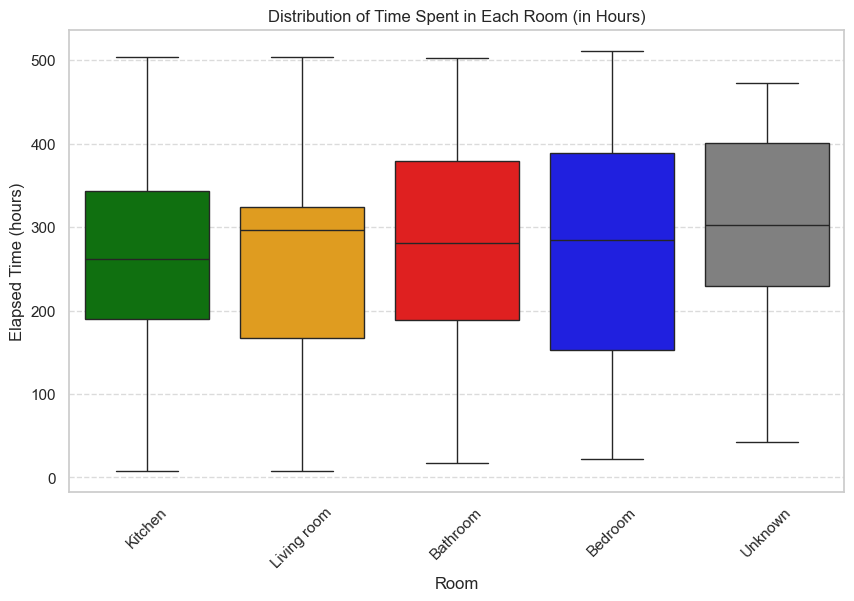

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

def read_csv_file(file_path):
    df = pd.read_csv(file_path)
    return df

def plot_total_time_in_room(df):
    room_categories = ["Bedroom", "Living room", "Kitchen", "Bathroom", "Work or Not at Home", "Unknown"]
    df = df[df['room'].isin(room_categories)]
    df['elapsed_time_hours'] = df['elapsed_time'] / 3600.0  # Convert seconds to hours
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df['room'], y=df['elapsed_time_hours'], palette={
        "Bedroom": "blue",
        "Living room": "orange",
        "Kitchen": "green",
        "Bathroom": "red",
        "Work or Not at Home": "purple",
        "Unknown": "gray"
    })
    
    plt.xlabel('Room')
    plt.ylabel('Elapsed Time (hours)')
    plt.title('Distribution of Time Spent in Each Room (in Hours)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
def main():


    df = read_csv_file('C:\\Users\\lollo\\Lavoro\\Ricerca\\energiai\\dataset\\sims\\Mario_Rossi.csv')
    plot_total_time_in_room(df)

if __name__ == '__main__':
    main()


In [ ]:
print(transitions)

   previous_room         room  count
0       Bathroom     Bathroom  12404
1       Bathroom      Kitchen     47
2       Bathroom      Unknown      1
3        Bedroom      Bedroom  43717
4        Bedroom      Kitchen     27
5        Bedroom      Unknown      2
6        Kitchen     Bathroom     47
7        Kitchen      Bedroom     28
8        Kitchen      Kitchen  13002
9        Kitchen  Living room     88
10       Kitchen      Unknown     15
11   Living room      Kitchen     88
12   Living room  Living room  75015
13   Living room      Unknown      1
14       Unknown     Bathroom      1
15       Unknown      Bedroom      2
16       Unknown      Kitchen     15
17       Unknown  Living room      1
18       Unknown      Unknown  17633


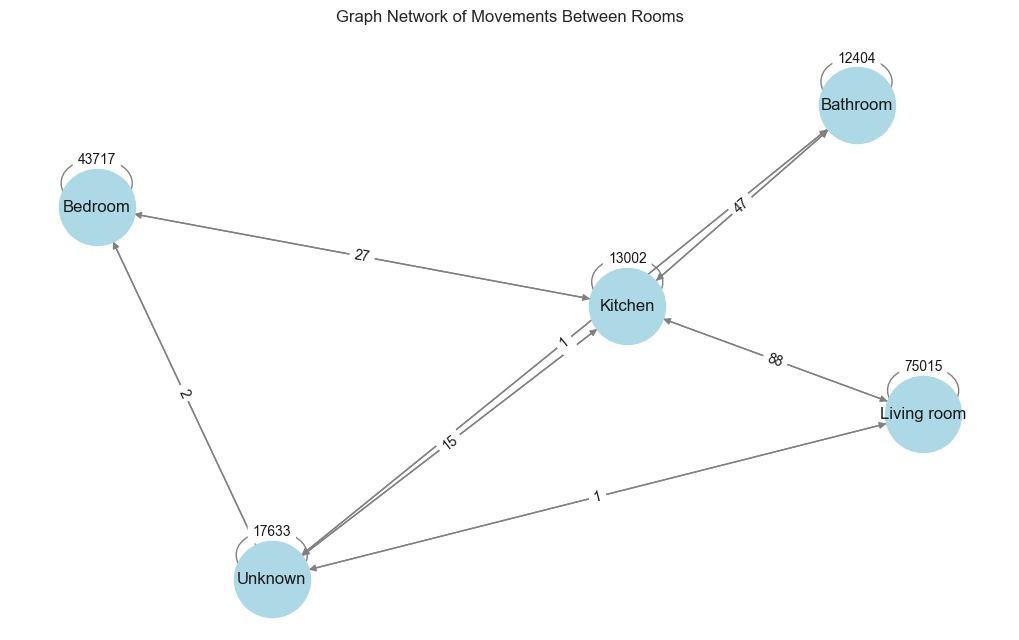

In [34]:
import networkx as nx


df["previous_room"] = df["room"].shift(1)
transitions = df.groupby(["previous_room", "room"]).size().reset_index(name="count")

# Creare il grafo
G = nx.DiGraph()

# Aggiungere nodi e archi
for _, row in transitions.iterrows():
    G.add_edge(row["previous_room"], row["room"], weight=row["count"])

# Disegnare il grafo
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)  # Layout del grafo
edges = G.edges(data=True)

# Disegnare nodi e archi
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", edge_color="gray")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d["weight"] for u, v, d in edges}, font_size=10)

plt.title("Graph Network of Movements Between Rooms")
plt.show()


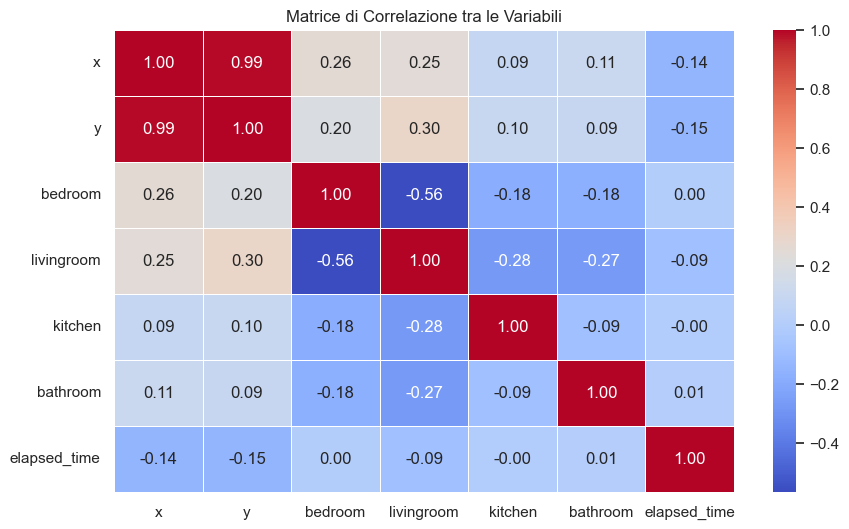

In [29]:
# Calcolare la matrice di correlazione
# correlation_matrix = df[["hygiene", "hunger", "bladder", "social", "energy", "fun", "elapsed_time"]].corr()
correlation_matrix = df.corr(method='pearson')

# Creare una heatmap per visualizzare la correlazione tra le variabili
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione tra le Variabili")
plt.show()